##  Heart Disease Prediction ML Model

In [1]:
## Importing the Libraires and Ingnoring the Warnings
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
## Loading the Dataset
df = pd.read_csv(r"C:\Users\arul9\Downloads\heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [3]:
## displaying the first five rows of the dataset
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
## displaying thr last five rows of the dataset
df.tail(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


In [5]:
## Getting the information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [6]:
## Getting the statistical information about the dataset only for the numerical columns
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [7]:
## Getting the statistical information about the dataset for all the columns
df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


In [8]:
## Counting the number of missing values in each column
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
## Checking the duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [10]:
## Displaying only the object type columns in the dataset
categorical_columns = df.select_dtypes(include='object').columns
categorical_columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='str')


#### Converting Categorical Variables to Numeric
- **Sex:** M = 0, F = 1
- **ChestPainType:** ATA = 0, NAP = 1, ASY = 2, TA = 3
- **Resting ECG:** Normal = 0, ST = 1, LVH = 2
- **ExerciseAngina:** N = 0, Y = 1
- **ST_Slope:** Up = 0, Flat = 1, Down = 2

### Unique and Nunique

* **Unique:** Gives the different/distinct values present in a particular column.

  **Example:**
  Gender → Male, Female, Male, Female, Male

  Unique values → Male, Female

---

* **Nunique:** Gives the **number of different/distinct values** present in a particular column.

  **Example:**
  Gender → Male, Female, Male, Female, Male

  Number of unique values → 2

  Because there are only **2 different values:**

  * Male
  * Female



In [11]:
## For our reference, we will check the unique values and the number of unique values in the "Sex" column.
print(df["Sex"].unique())
print(df["Sex"].nunique())

<ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
2


In [12]:
for column in categorical_columns:

    unique_values = df[column].unique()
    numbers = list(range(df[column].nunique()))

    print(column)
    print("Before:", unique_values)
    print("Numbers:", numbers)

    df[column] = df[column].replace(unique_values, numbers)

# Display converted dataset
print("\nAfter conversion:")
print(df.head())

# Check data types
print("\nData types:")
print(df.dtypes)

Sex
Before: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
Numbers: [0, 1]
ChestPainType
Before: <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
Numbers: [0, 1, 2, 3]
RestingECG
Before: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
Numbers: [0, 1, 2]
ExerciseAngina
Before: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
Numbers: [0, 1]
ST_Slope
Before: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str
Numbers: [0, 1, 2]

After conversion:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   0             0        140          289          0          0    172   
1   49   1             1        160          180          0          0    156   
2   37   0             0        130          283          0          1     98   
3   48   1             2        138          214          0          0    108   
4   54   0             1        150          195          0          0    122   

  Exerc

In [13]:
## Now You can see that the object type columns have been converted into numerical columns.
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,1,1
914,68,0,2,144,193,1,0,141,0,3.4,1,1
915,57,0,2,130,131,0,0,115,1,1.2,1,1
916,57,1,0,130,236,0,2,174,0,0.0,1,1


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

## Step 1 — Separate features (X) and target (y)
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

## Step 2 — Train/Test split (before imputing, to avoid data leakage)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Step 3 — Replace invalid 0 values with NaN (only in X_train and X_test)
X_train["Cholesterol"] = X_train["Cholesterol"].replace(0, np.nan)
X_test["Cholesterol"] = X_test["Cholesterol"].replace(0, np.nan)

X_train["RestingBP"] = X_train["RestingBP"].replace(0, np.nan)
X_test["RestingBP"] = X_test["RestingBP"].replace(0, np.nan)

## Step 4 — Fit KNN Imputer ONLY on X_train, then transform both
imputer = KNNImputer(n_neighbors=3)

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

## Step 5 — Save the correctly-fit imputer
import pickle
with open("KNN_Imputer.pkl", "wb") as file:
    pickle.dump(imputer, file)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Missing values remaining in X_train:", X_train.isnull().sum().sum())
print("Missing values remaining in X_test:", X_test.isnull().sum().sum())

X_train shape: (734, 11)
X_test shape: (184, 11)
Missing values remaining in X_train: 0
Missing values remaining in X_test: 0


In [15]:
df.head(176)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
171,40,0,1,140,235,0,0,188,0,0.0,0,0
172,53,0,0,140,320,0,0,162,0,0.0,0,0
173,49,0,1,140,187,0,0,172,0,0.0,0,0
174,52,0,2,140,266,0,0,134,1,2.0,1,1


In [16]:
!pip install matplotlib


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
df.corr()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
Age,1.000000,-0.055750,0.214164,0.254399,-0.095282,0.198039,0.213152,-0.382045,0.215793,0.258612,0.268264,0.282039
Sex,-0.055750,1.000000,-0.179766,-0.005133,0.200092,-0.120076,0.018343,0.189186,-0.190664,-0.105734,-0.150693,-0.305445
ChestPainType,0.214164,-0.179766,1.000000,0.075332,-0.130997,0.155111,0.112067,-0.273076,0.324049,0.300846,0.352364,0.459017
RestingBP,0.254399,-0.005133,0.075332,1.000000,0.100893,0.070193,0.097661,-0.112135,0.155101,0.164803,0.075162,0.107589
Cholesterol,-0.095282,0.200092,-0.130997,0.100893,1.000000,-0.260974,0.112095,0.235792,-0.034166,0.050148,-0.111471,-0.232741
FastingBS,0.198039,-0.120076,0.155111,0.070193,-0.260974,1.000000,0.050707,-0.131438,0.060451,0.052698,0.175774,0.267291
RestingECG,0.213152,0.018343,0.112067,0.097661,0.112095,0.050707,1.000000,0.048552,0.036119,0.114428,0.078807,0.061011
MaxHR,-0.382045,0.189186,-0.273076,-0.112135,0.235792,-0.131438,0.048552,1.000000,-0.370425,-0.160691,-0.343419,-0.400421
ExerciseAngina,0.215793,-0.190664,0.324049,0.155101,-0.034166,0.060451,0.036119,-0.370425,1.000000,0.408752,0.428706,0.494282
Oldpeak,0.258612,-0.105734,0.300846,0.164803,0.050148,0.052698,0.114428,-0.160691,0.408752,1.000000,0.501921,0.403951


In [18]:
df.corr()["HeartDisease"][:-1].sort_values()

MaxHR            -0.400421
Sex              -0.305445
Cholesterol      -0.232741
RestingECG        0.061011
RestingBP         0.107589
FastingBS         0.267291
Age               0.282039
Oldpeak           0.403951
ChestPainType     0.459017
ExerciseAngina    0.494282
ST_Slope          0.558771
Name: HeartDisease, dtype: float64

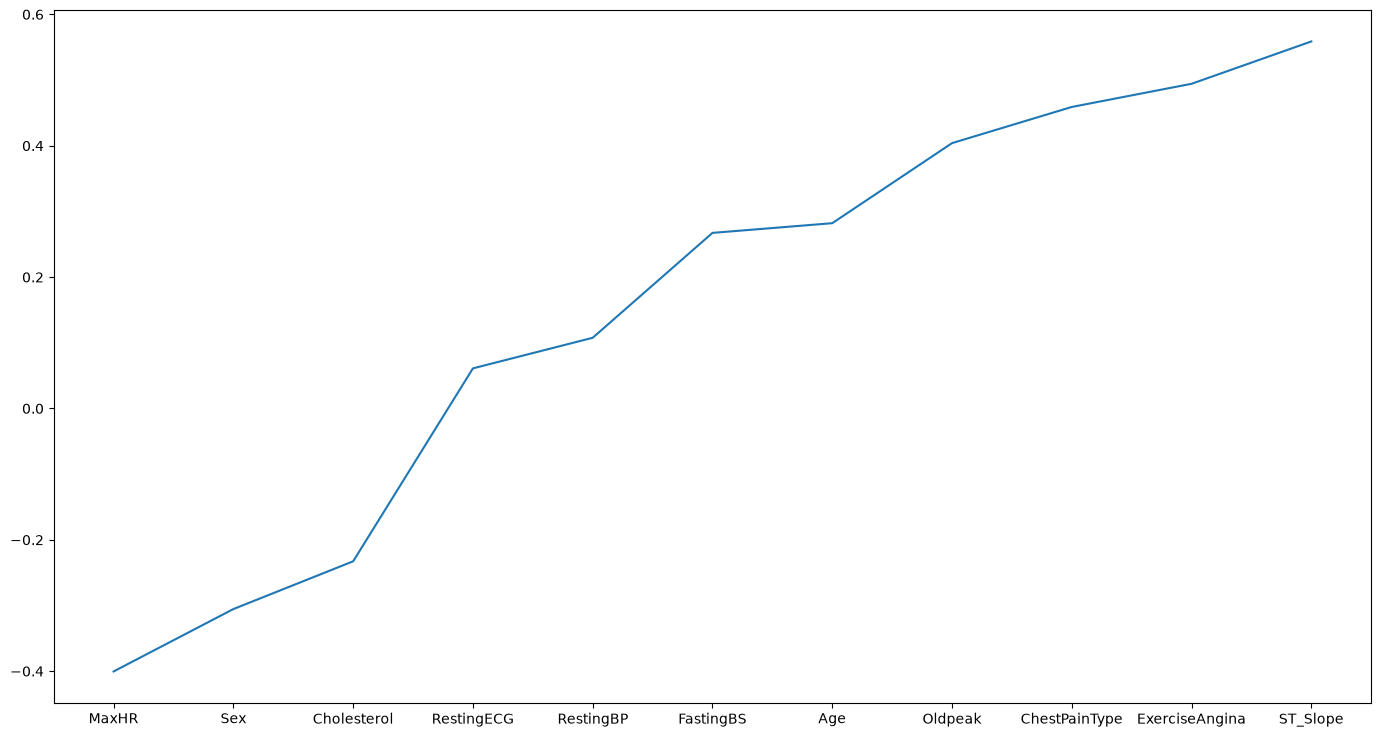

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(17, 9))
plt.plot(df.corr()["HeartDisease"][:-1].sort_values())
plt.show()

<Axes: title={'center': 'No Heart Disease'}, ylabel='Frequency'>

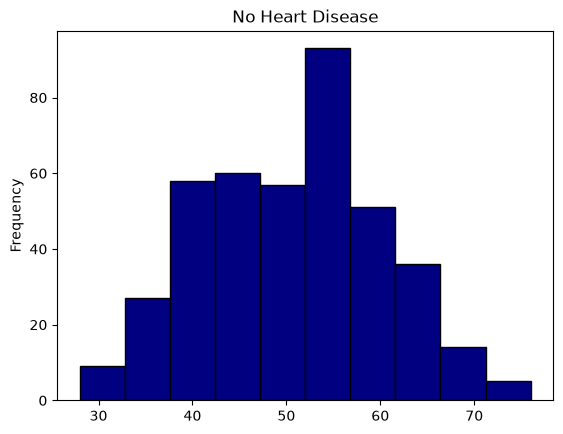

In [20]:
## Correlation between the Heart Diseases and Age of the patients 
df[df["HeartDisease"] == 0]["Age"].plot(kind="hist", title="No Heart Disease", edgecolor="black",color="navy")

<Axes: title={'center': 'Heart Disease'}, ylabel='Frequency'>

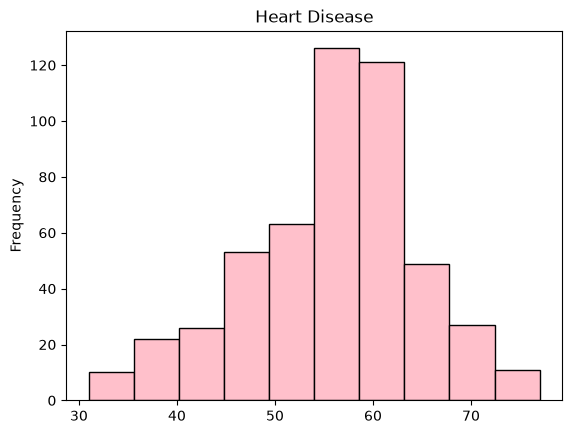

In [21]:
## correlation between the Heart Diseases and Age of the patients
df[df["HeartDisease"] == 1]["Age"].plot(kind="hist", title="Heart Disease", edgecolor="black", color="pink")

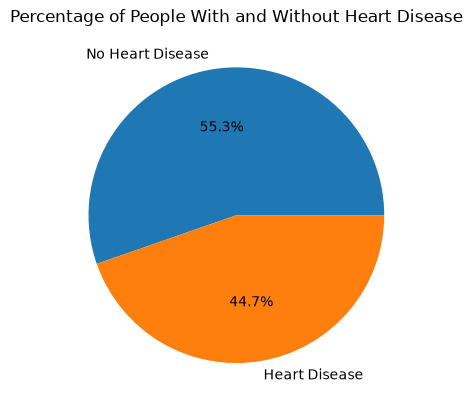

In [22]:
plt.pie(df["HeartDisease"].value_counts(), labels=["No Heart Disease", "Heart Disease"], autopct="%1.1f%%")
plt.title("Percentage of People With and Without Heart Disease")
plt.show()

<Axes: ylabel='Frequency'>

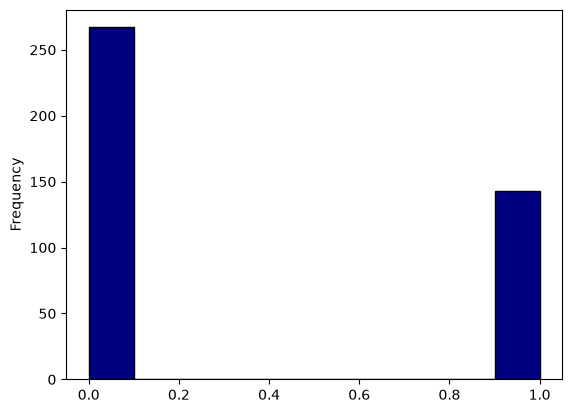

In [23]:
## correlation between the Heart Diseases and Sex of the patients
df[df["HeartDisease"]==0]["Sex"].plot(kind='hist', edgecolor='black', color='navy')

<Axes: ylabel='Frequency'>

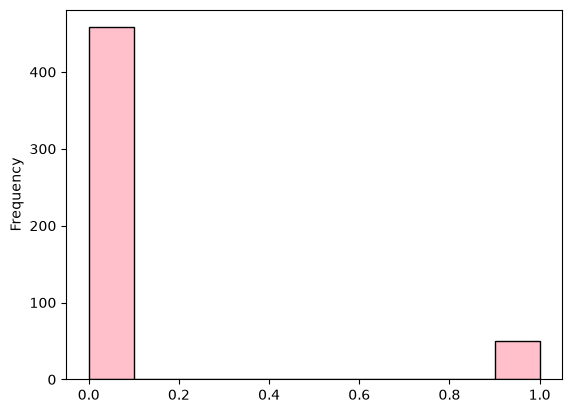

In [24]:
df[df["HeartDisease"]==1]["Sex"].plot(kind='hist', edgecolor='black', color='pink')

<Axes: ylabel='Frequency'>

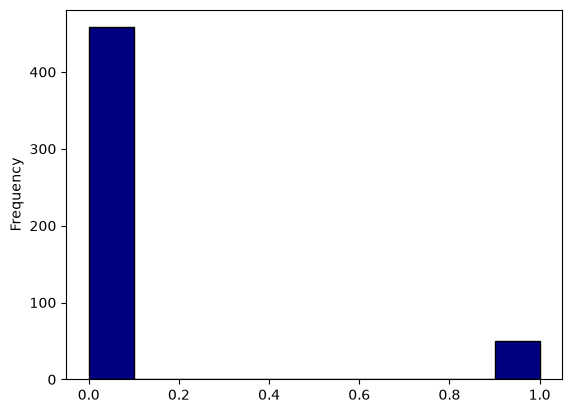

In [25]:
df[df["HeartDisease"]==1]["Sex"].plot(kind='hist', edgecolor='black', color='navy')

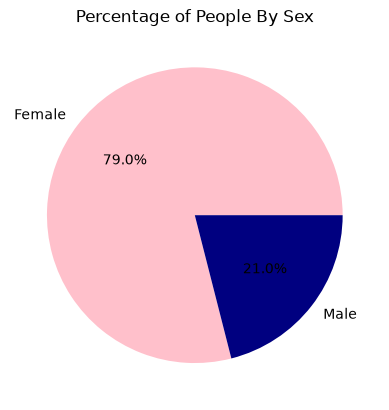

In [26]:
plt.pie(df["Sex"].value_counts(), labels=["Female", "Male"], autopct="%1.1f%%",colors=['pink','navy'])
plt.title("Percentage of People By Sex")
plt.show()  

In [27]:
## Training and Testing the Dataset
# X _Train  - Features of training dataset , 
# X_test    - Features of testing dataset, 
# Y_train   - Target variable of training dataset, 
# Y_test    - Target variable of testing dataset 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
X_train, X_test, Y_train, Y_test = train_test_split(
    df.drop("HeartDisease", axis=1),
    df["HeartDisease"],
    test_size=0.2,
    random_state=42
)
My_model = LogisticRegression()
My_model.fit(X_train,Y_train)
Prediction = My_model.predict(X_test)
Accuracy = accuracy_score(Y_test, Prediction)
print("Accuracy logistic:", Accuracy*100,"%")


Accuracy logistic: 84.23913043478261 %


In [28]:
import pickle
file = open('LogistiRegression.pkl', 'wb')
pickle.dump(My_model, file)
file.close()

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dtree = DecisionTreeClassifier()

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 3, 4],
    'random_state': [42]
}

grid_search = GridSearchCV(
    dtree,
    param_grid=param_grid,
    cv=5
)

#Train GridSearchCV
grid_search.fit(X_train, Y_train)

# Best Parameters
print(grid_search.best_params_)

# Create the final model using the best parameters
ctree = DecisionTreeClassifier(
    **grid_search.best_params_,
    class_weight='balanced'
)
## Finding the accuracy of the model using the best parameters
ctree.fit(X_train, Y_train)
Prediction = ctree.predict(X_test)
Accuracy = accuracy_score(Y_test, Prediction)
print("Accuracy deciosion tree:", Accuracy*100,"%")

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2, 'random_state': 42}
Accuracy deciosion tree: 84.78260869565217 %


In [30]:
import pickle
file = open('Decision_Tree.pkl', 'wb')
pickle.dump(ctree, file)
file.close()

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

rfc = RandomForestClassifier()
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [2, 3, 5],
    'max_leaf_nodes': [2, 3, 5]
}

Randomized_search = GridSearchCV(
    rfc,
    param_grid=param_grid,
    cv=5
)

Randomized_search.fit(X_train, Y_train)
print("Best Parameters:", Randomized_search.best_params_)
R_tree = RandomForestClassifier(**Randomized_search.best_params_)
R_tree.fit(X_train, Y_train)
Prediction = R_tree.predict(X_test)
Accuracy = accuracy_score(Y_test, Prediction)
print("Accuracy randomforest:", Accuracy * 100, "%")


Best Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'max_leaf_nodes': 5, 'n_estimators': 200}
Accuracy randomforest: 83.69565217391305 %


In [32]:
import pickle
file = open('Random_Forest.pkl', 'wb')
pickle.dump(R_tree, file)
file.close()

In [33]:
!pip install streamlit


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
pip show streamlit

Name: streamlit
Version: 1.63.0
Summary: A faster way to build and share data apps
Home-page: https://streamlit.io
Author: 
Author-email: Snowflake Inc <hello@streamlit.io>
License-Expression: Apache-2.0
Location: c:\Users\arul9\OneDrive\Documents\ML Project\Student_Placement_Prediction\venv\Lib\site-packages
Requires: altair, anyio, click, httptools, itsdangerous, numpy, packaging, pandas, pillow, protobuf, pyarrow, pydeck, python-multipart, requests, starlette, toml, typing-extensions, uvicorn, watchdog, websockets
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [35]:
## --------------------------------------------------
## Save Model Accuracies (for dynamic Streamlit display)
## --------------------------------------------------

import json

model_accuracies = {
    "Logistic Regression": round(accuracy_score(Y_test, My_model.predict(X_test)) * 100, 2),
    "Decision Tree": round(accuracy_score(Y_test, ctree.predict(X_test)) * 100, 2),
    "Random Forest": round(accuracy_score(Y_test, R_tree.predict(X_test)) * 100, 2)
}

with open("model_accuracies.json", "w") as f:
    json.dump(model_accuracies, f, indent=4)

print("Saved accuracies:", model_accuracies)

Saved accuracies: {'Logistic Regression': 84.24, 'Decision Tree': 84.78, 'Random Forest': 83.7}


In [36]:
import os

files = ['LogistiRegression.pkl', 'Decision_Tree.pkl', 'Random_Forest.pkl']

for fname in files:
    print("=" * 50)
    print("File:", fname)

    if not os.path.exists(fname):
        print("  -> FILE NOT FOUND in this folder!")
        continue

    size = os.path.getsize(fname)
    print("  Size:", size, "bytes")

    with open(fname, 'rb') as f:
        first_bytes = f.read(30)
        print("  First bytes:", repr(first_bytes))

    if first_bytes[:1] == b'\x80':
        print("  -> Looks like a VALID pickle file (starts with \\x80).")
    elif b'version https://git-lfs' in first_bytes:
        print("  -> This is a GIT LFS POINTER file, not the real model!")
    elif first_bytes[:3] == b'\xef\xbb\xbf' or first_bytes.strip()[:1] in (b'<', b'{'):
        print("  -> This looks like TEXT/HTML, not a real pickle file!")
    else:
        print("  -> Unrecognized format, needs manual check.")

print("=" * 50)
print("Done. Copy this whole output and share it.")

File: LogistiRegression.pkl
  Size: 1020 bytes
  First bytes: b'\x80\x05\x95\xf1\x03\x00\x00\x00\x00\x00\x00\x8c\x1esklearn.linear_mo'
  -> Looks like a VALID pickle file (starts with \x80).
File: Decision_Tree.pkl
  Size: 2543 bytes
  First bytes: b'\x80\x05\x95\xe4\t\x00\x00\x00\x00\x00\x00\x8c\x15sklearn.tree._cla'
  -> Looks like a VALID pickle file (starts with \x80).
File: Random_Forest.pkl
  Size: 201601 bytes
  First bytes: b'\x80\x05\x95\x01\x00\x01\x00\x00\x00\x00\x00\x8c\x18sklearn.ensemble.'
  -> Looks like a VALID pickle file (starts with \x80).
Done. Copy this whole output and share it.


In [37]:
import pickle

file1 = open('LogistiRegression.pkl', 'rb')
My_model_loaded = pickle.load(file1)
file1.close()
print("LogistiRegression.pkl ->", type(My_model_loaded))

file2 = open('Decision_Tree.pkl', 'rb')
ctree_loaded = pickle.load(file2)
file2.close()
print("Decision_Tree.pkl ->", type(ctree_loaded))

file3 = open('Random_Forest.pkl', 'rb')
R_tree_loaded = pickle.load(file3)
file3.close()
print("Random_Forest.pkl ->", type(R_tree_loaded))

LogistiRegression.pkl -> <class 'sklearn.linear_model._logistic.LogisticRegression'>
Decision_Tree.pkl -> <class 'sklearn.tree._classes.DecisionTreeClassifier'>
Random_Forest.pkl -> <class 'sklearn.ensemble._forest.RandomForestClassifier'>
